In [1]:
from loguru import logger
logger.remove()
import sys
logger.add(sys.stderr, level="INFO")

import gc
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    context="paper",
    style="ticks",
    palette="Set2",
    rc={
        "figure.dpi": 600, "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "figure.labelsize": "small",
    },
)

from lib._notebook_helpers import (
    get_scorer_kwargs,
    load_decoding_data_streaming,
    load_bhv_decoding_data_streaming,
    load_cvpca_dimensionality_streaming,
    add_time_markers,
    plot_significance_bar,
)
from lib.datasets import load_n_subjects

In [2]:
# Configuration
N_PERMUTATIONS = 1000  # Change this to match your data

/tmp/ipykernel_24027/1172483725.py:58: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.lineplot(data=xdf, x="time", y="score", ax=ax_dec_eeg, palette=sns.color_palette("Blues_r", n_colors=4), hue="node", errorbar=None)
/tmp/ipykernel_24027/1172483725.py:132: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.lineplot(data=xdf, x="time", y="score", ax=ax_dec_meg, palette=sns.color_palette("Blues_r", n_colors=4), hue="node", errorbar=None)


345

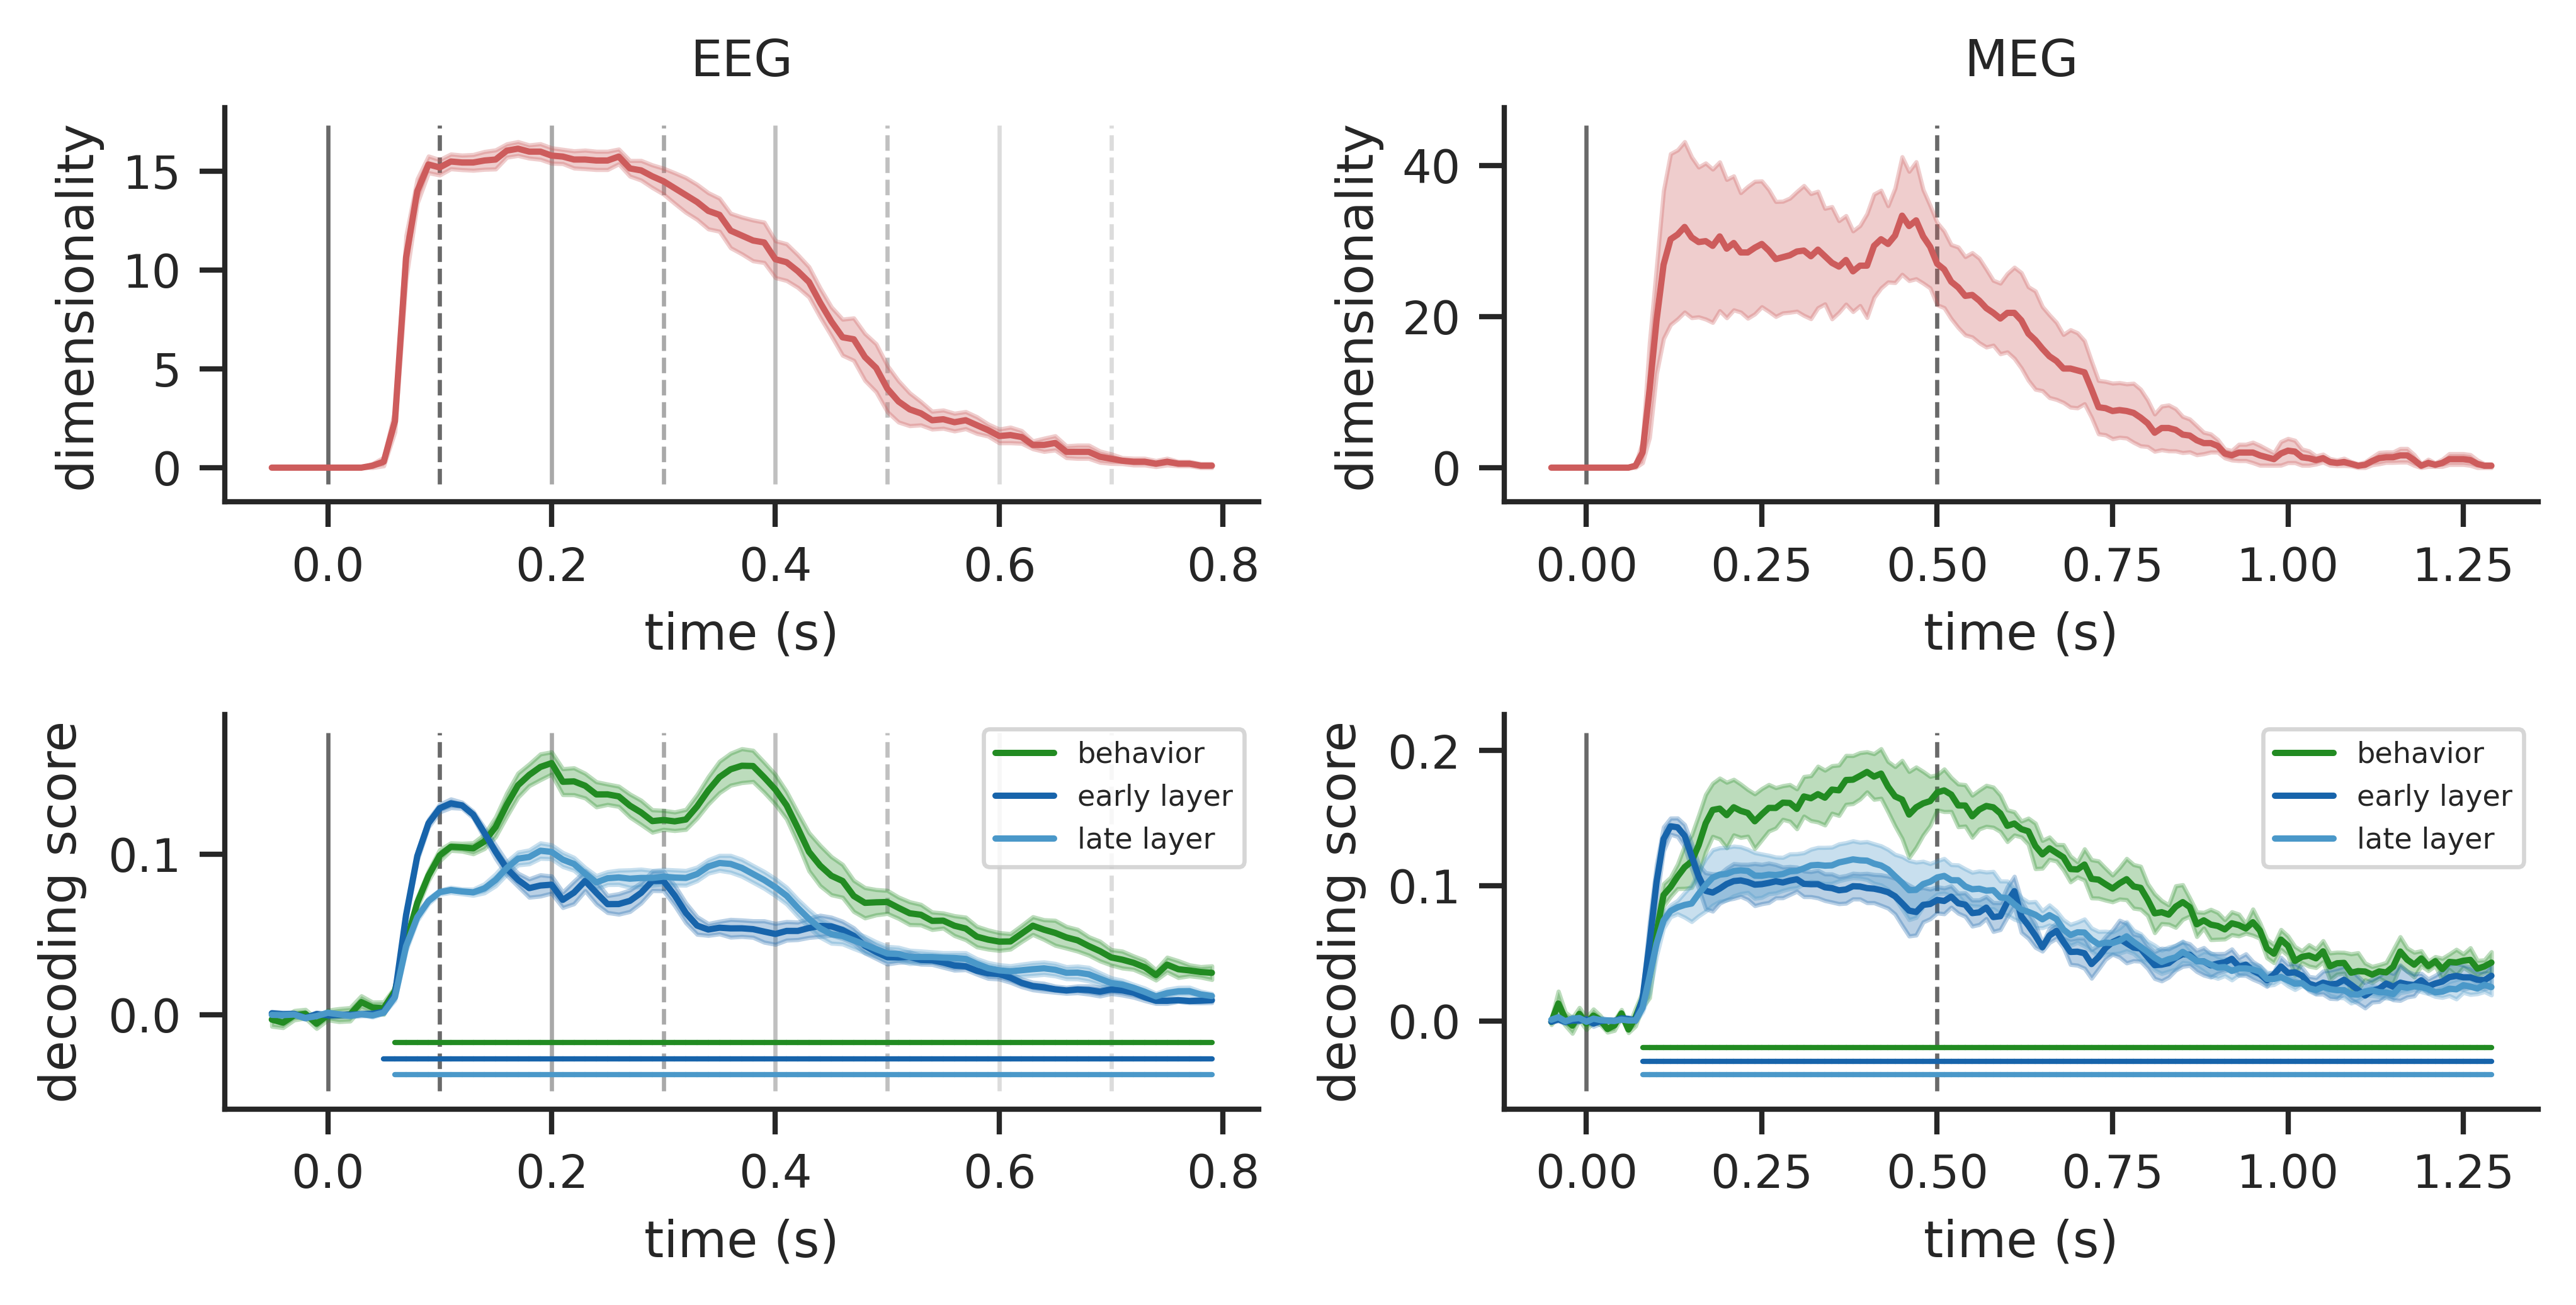

In [5]:
plt.close()
width_mm = 180
width_inches = width_mm / 25.4
height_inches = width_inches / 2
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=False, sharey=False, figsize=(width_inches, height_inches))

dataset = "things_eeg_2"
folds = False
decoding_str = ".subset=False.pca=False"
load_dataset_kwargs = "default"
model_uid = "openclip_rn50_yfcc15m"

########## EEG dimensionality (top left) ##########
ax_dim_eeg = axs[0, 0]
ax_dim_eeg.set_title("EEG")

cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"
cdf = load_cvpca_dimensionality_streaming(cvpca_path, "EEG")

sns.lineplot(data=cdf, x="time", y="cvnsr", ax=ax_dim_eeg, label="EEG dimensionality", color="indianred", errorbar=None, legend=False)
score = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").mean().values
err = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").sem().values
ax_dim_eeg.fill_between(cdf.time.unique(), score - err, score + err, color="indianred", alpha=0.3)

ax_dim_eeg.set(ylabel="dimensionality", xlabel="time (s)")
ax_dim_eeg.spines['top'].set_visible(False)
ax_dim_eeg.spines['right'].set_visible(False)

ymin, ymax = ax_dim_eeg.get_ylim()
add_time_markers(ax_dim_eeg, dataset, ymin, ymax)

del cdf
gc.collect()

########## EEG decoding results (bottom left) ##########
ax_dec_eeg = axs[1, 0]

scorer_kwargs, target_var = get_scorer_kwargs("linear")
subpath = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/model_srpz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}/model_kwargs=model_uid={model_uid}.n_components=auto"

xdf, sig_times = load_decoding_data_streaming(
    subpath, dataset, N_PERMUTATIONS, target_var, folds=folds, has_node=True
)
node_values = xdf["node"].unique()

bhv_scorer_kwargs = "model_name=linear.l2_penalty=0.01"
bhv_subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/behaviorz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={bhv_scorer_kwargs}")
bhv_xdf, bhv_sxdf = load_bhv_decoding_data_streaming(
    bhv_subpath, dataset, N_PERMUTATIONS, "neuroid", folds=folds
)
bhv_xdf = bhv_xdf[bhv_xdf.metric == "pearsonr"]

sns.lineplot(data=bhv_xdf, x="time", y="score", ax=ax_dec_eeg, color="forestgreen", label="behavior", errorbar=None)
score = bhv_xdf.groupby(["time", "subject"]).score.mean().groupby("time").mean().values
err = bhv_xdf.groupby(["time", "subject"]).score.mean().groupby("time").sem().values
ax_dec_eeg.fill_between(bhv_xdf.time.unique(), score - err, score + err, color="forestgreen", alpha=0.3)

sns.lineplot(data=xdf, x="time", y="score", ax=ax_dec_eeg, palette=sns.color_palette("Blues_r", n_colors=4), hue="node", errorbar=None)
for i, node_name in enumerate(node_values):
    node_data = xdf[xdf["node"] == node_name]
    color = sns.color_palette("Blues_r", n_colors=4)[i]
    score = node_data.groupby(["time", "subject"]).score.mean().groupby("time").mean().values
    err = node_data.groupby(["time", "subject"]).score.mean().groupby("time").sem().values
    ax_dec_eeg.fill_between(node_data.time.unique(), score - err, score + err, color=color, alpha=0.3)

handles, labels = ax_dec_eeg.get_legend_handles_labels()
ax_dec_eeg.legend(handles[:3], ["behavior", "early layer", "late layer"], loc='upper right', fontsize='xx-small')

ax_dec_eeg.set(ylabel="decoding score", xlabel="time (s)")
ax_dec_eeg.spines['top'].set_visible(False)
ax_dec_eeg.spines['right'].set_visible(False)

times = bhv_xdf.time.unique()
ypos = ax_dec_eeg.get_ylim()[0]
plot_significance_bar(ax_dec_eeg, bhv_sxdf['time'].values, times, ypos, "forestgreen")
for i, node in enumerate(node_values):
    plot_significance_bar(ax_dec_eeg, sig_times[node], times, ypos - 0.01 - 0.01 * i, sns.color_palette("Blues_r", n_colors=4)[i])

ymin, ymax = ax_dec_eeg.get_ylim()
add_time_markers(ax_dec_eeg, dataset, ymin, ymax)

del xdf, bhv_xdf, bhv_sxdf
gc.collect()

########## MEG dimensionality (top right) ##########
dataset = "things_meg"
load_dataset_kwargs = "from_raw=1.downsample_freq=100.h_freq=100.baseline=(None, 0).rois=op"

ax_dim_meg = axs[0, 1]
ax_dim_meg.set_title("MEG")

cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"
cdf = load_cvpca_dimensionality_streaming(cvpca_path, "MEG")

sns.lineplot(data=cdf, x="time", y="cvnsr", ax=ax_dim_meg, label="MEG dimensionality", color="indianred", errorbar=None, legend=False)
score = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").mean().values
err = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").sem().values
ax_dim_meg.fill_between(cdf.time.unique(), score - err, score + err, color="indianred", alpha=0.3)

ax_dim_meg.set(ylabel="dimensionality", xlabel="time (s)")
ax_dim_meg.spines['top'].set_visible(False)
ax_dim_meg.spines['right'].set_visible(False)

ymin, ymax = ax_dim_meg.get_ylim()
add_time_markers(ax_dim_meg, dataset, ymin, ymax)

del cdf
gc.collect()

########## MEG decoding results (bottom right) ##########
ax_dec_meg = axs[1, 1]

scorer_kwargs, target_var = get_scorer_kwargs("linear")
subpath = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/model_srpz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}/model_kwargs=model_uid={model_uid}.n_components=auto"

xdf, sig_times = load_decoding_data_streaming(
    subpath, dataset, N_PERMUTATIONS, target_var, folds=folds, has_node=True
)
node_values = xdf["node"].unique()

bhv_subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/behaviorz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={bhv_scorer_kwargs}")
bhv_xdf, bhv_sxdf = load_bhv_decoding_data_streaming(
    bhv_subpath, dataset, N_PERMUTATIONS, "neuroid", folds=folds
)
bhv_xdf = bhv_xdf[bhv_xdf.metric == "pearsonr"]

sns.lineplot(data=bhv_xdf, x="time", y="score", ax=ax_dec_meg, color="forestgreen", label="behavior", errorbar=None)
score = bhv_xdf.groupby(["time", "subject"]).score.mean().groupby("time").mean().values
err = bhv_xdf.groupby(["time", "subject"]).score.mean().groupby("time").sem().values
ax_dec_meg.fill_between(bhv_xdf.time.unique(), score - err, score + err, color="forestgreen", alpha=0.3)

sns.lineplot(data=xdf, x="time", y="score", ax=ax_dec_meg, palette=sns.color_palette("Blues_r", n_colors=4), hue="node", errorbar=None)
for i, node_name in enumerate(node_values):
    node_data = xdf[xdf["node"] == node_name]
    color = sns.color_palette("Blues_r", n_colors=4)[i]
    score = node_data.groupby(["time", "subject"]).score.mean().groupby("time").mean().values
    err = node_data.groupby(["time", "subject"]).score.mean().groupby("time").sem().values
    ax_dec_meg.fill_between(node_data.time.unique(), score - err, score + err, color=color, alpha=0.3)

handles, labels = ax_dec_meg.get_legend_handles_labels()
ax_dec_meg.legend(handles[:3], ["behavior", "early layer", "late layer"], loc='upper right', fontsize='xx-small')

ax_dec_meg.set(ylabel="decoding score", xlabel="time (s)")
ax_dec_meg.spines['top'].set_visible(False)
ax_dec_meg.spines['right'].set_visible(False)

times = bhv_xdf.time.unique()
ypos = ax_dec_meg.get_ylim()[0]
plot_significance_bar(ax_dec_meg, bhv_sxdf['time'].values, times, ypos, "forestgreen")
for i, node in enumerate(node_values):
    plot_significance_bar(ax_dec_meg, sig_times[node], times, ypos - 0.01 - 0.01 * i, sns.color_palette("Blues_r", n_colors=4)[i])

ymin, ymax = ax_dec_meg.get_ylim()
add_time_markers(ax_dec_meg, dataset, ymin, ymax)

plt.tight_layout()

del xdf, bhv_xdf, bhv_sxdf
gc.collect()